In [1]:
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
from transformers import BertTokenizer, BertModel
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# === CONFIG ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_dir = "../dataset/spectograms/mel_graphic"
text_dir = "../dataset/Lyrics"
classes_path = "../dataset/classes.txt"
batch_size = 16
num_epochs = 7
learning_rate = 0.0001

In [3]:
# === LABELS ===
with open(classes_path, "r") as f:
    class_lines = [line.strip() for line in f.readlines()]  # np. ["positive", "negative", "positive", ...]

# Zidentyfikuj unikalne klasy i przypisz im liczby
unique_classes = sorted(set(class_lines))  # ['hateful', 'negative', 'positive'] np.
class_to_idx = {cls: idx for idx, cls in enumerate(unique_classes)}  # {'hateful': 0, 'negative': 1, 'positive': 2}

# labels_dict: klucz to ID (str), wartość to indeks klasy (int)
labels_dict = {str(i): class_to_idx[class_lines[i]] for i in range(len(class_lines))}

print("Znalezione klasy:", class_to_idx)


Znalezione klasy: {'negative': 0, 'nostalgic': 1, 'positive': 2}


In [4]:
unique_classes

['negative', 'nostalgic', 'positive']

In [5]:
from collections import Counter

# === OBLICZ WAGI KLAS ===
# Wyciągamy listę indeksów klas
label_indices = list(labels_dict.values())

# Liczymy wystąpienia każdej klasy
class_counts = Counter(label_indices)

# Obliczamy wagi: im mniej próbek w klasie, tym większa waga
total_samples = sum(class_counts.values())
num_classes = len(unique_classes)
class_weights = []

for i in range(num_classes):
    count = class_counts.get(i, 1)  # zabezpieczenie przed dzieleniem przez 0
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)

# Zamiana na tensor
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Wagi klas:", {unique_classes[i]: round(w, 2) for i, w in enumerate(class_weights)})

Wagi klas: {'negative': 1.5, 'nostalgic': 1.14, 'positive': 0.69}


In [6]:
from pathlib import Path

class MultimodalDataset(Dataset):
    def __init__(self, image_dir, text_dir, labels_dict, tokenizer, transform=None):
        self.image_dir = Path(image_dir)
        self.text_dir = Path(text_dir)
        self.labels_dict = labels_dict
        self.tokenizer = tokenizer
        self.transform = transform
        self.file_ids = list(labels_dict.keys())

    def __getitem__(self, idx):
        file_id = self.file_ids[idx]
        label = self.labels_dict[file_id]

        # === OBRAZ ===
        image_path = self.image_dir / f"{int(file_id) + 1:03d}_mel.png"


        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # === TEKST ===
        text_path = self.text_dir / (file_id + ".txt")

        if text_path.exists():
            with open(text_path, 'r', encoding='utf-8') as f:
                text = f.read()
        else:
            text = ""  # lub np. "[NO TEXT]" jeśli chcesz oznaczyć brak tekstu
            
        encoding = self.tokenizer(text, padding='max_length', truncation=True, max_length=128, return_tensors='pt')

        return {
            'image': image,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

    def __len__(self):
        return len(self.file_ids)


In [7]:
# === TRANSFORMS & TOKENIZER ===
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.5]*3, [0.5]*3)
# ])

transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5),
    transforms.RandomGrayscale(p = 0.1),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [8]:
file_ids = list(labels_dict.keys())
labels = list(labels_dict.values())

In [9]:
# === MODEL ===
class MultimodalClassifier(nn.Module):
    def __init__(self, num_classes):
        super(MultimodalClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.cnn = models.regnet_y_800mf(weights=models.RegNet_Y_800MF_Weights.DEFAULT)
        self.cnn.fc = nn.Identity()  # remove classification layer

        self.fc = nn.Sequential(
            #nn.Linear(1208, 512), # dla 400
            nn.Linear(768 + 784, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )


    def forward(self, input_ids, attention_mask, images):
        text_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = text_output.pooler_output  # shape: (B, 768)

        image_feat = self.cnn(images)  # shape: (B, 1000)

        combined = torch.cat((text_feat, image_feat), dim=1)
        out = self.fc(combined)
        return out


=== Fold 1/5 ===
Fold 1 Results:
Accuracy: 0.5490, Precision: 0.5617, Recall: 0.5490, F1: 0.5541


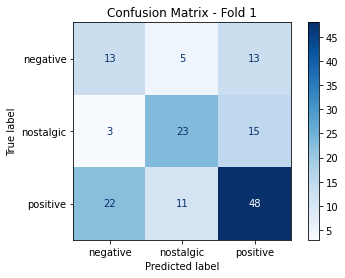


=== Fold 2/5 ===
Fold 2 Results:
Accuracy: 0.5359, Precision: 0.5908, Recall: 0.5359, F1: 0.5510


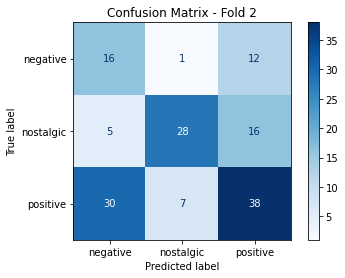


=== Fold 3/5 ===
Fold 3 Results:
Accuracy: 0.6471, Precision: 0.6630, Recall: 0.6471, F1: 0.6250


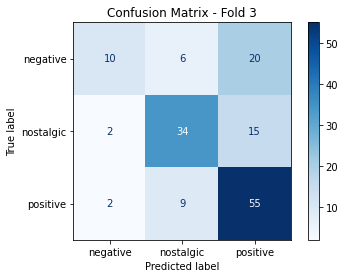


=== Fold 4/5 ===
Fold 4 Results:
Accuracy: 0.6144, Precision: 0.6134, Recall: 0.6144, F1: 0.6075


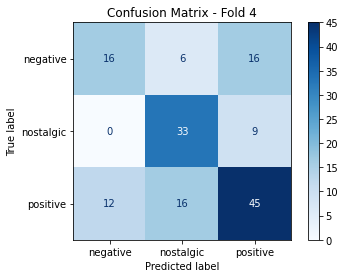


=== Fold 5/5 ===
Fold 5 Results:
Accuracy: 0.6053, Precision: 0.6158, Recall: 0.6053, F1: 0.6060


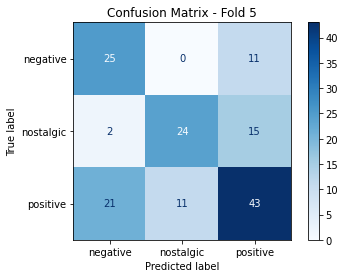

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold

k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

full_dataset = MultimodalDataset(image_dir, text_dir, labels_dict, tokenizer, transform)

fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_f1s = []

for fold, (train_idx, val_idx) in enumerate(kf.split(full_dataset)):
    print(f"\n=== Fold {fold+1}/{k_folds} ===")

    # Przygotowanie danych
    train_subset = torch.utils.data.Subset(full_dataset, train_idx)
    val_subset = torch.utils.data.Subset(full_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size)

    model = MultimodalClassifier(num_classes=len(unique_classes)).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    best_val_acc = 0.0
    best_model_path = f"best_model_fold{fold+1}_lr{learning_rate}_bs{batch_size}.pth"

    # === Trenowanie ===
    for epoch in range(num_epochs):
        model.train()
        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask, images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Walidacja
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                images = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(input_ids, attention_mask, images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

    # === Ewaluacja najlepszego modelu ===
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # === Metryki ===
    report = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
    accuracy = report["accuracy"]
    precision = report["weighted avg"]["precision"]
    recall = report["weighted avg"]["recall"]
    f1 = report["weighted avg"]["f1-score"]

    fold_accuracies.append(accuracy)
    fold_precisions.append(precision)
    fold_recalls.append(recall)
    fold_f1s.append(f1)

    print(f"Fold {fold+1} Results:")
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    # === Macierz konfuzji ===
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(unique_classes))
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - Fold {fold+1}")
    plt.show()


In [11]:
# === Podsumowanie średnich metryk ===
mean_accuracy = np.mean(fold_accuracies)
mean_precision = np.mean(fold_precisions)
mean_recall = np.mean(fold_recalls)
mean_f1 = np.mean(fold_f1s)

print("\n=== Średnie metryki po 5-krotnej walidacji krzyżowej ===")
print(f"Średnia Accuracy: {mean_accuracy:.4f}")
print(f"Średnia Precision: {mean_precision:.4f}")
print(f"Średnia Recall: {mean_recall:.4f}")
print(f"Średnia F1-score: {mean_f1:.4f}")


=== Średnie metryki po 5-krotnej walidacji krzyżowej ===
Średnia Accuracy: 0.5903
Średnia Precision: 0.6089
Średnia Recall: 0.5903
Średnia F1-score: 0.5887


In [15]:
import torch
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset

# Ścieżki do zapisanych modeli
model_paths = [
    "../early_fusion/best_model_fold1_lr0.0001_bs16.pth",
    "../early_fusion/best_model_fold2_lr0.0001_bs16.pth",
    "../early_fusion/best_model_fold3_lr0.0001_bs16.pth",
    "../early_fusion/best_model_fold4_lr0.0001_bs16.pth",
    "../early_fusion/best_model_fold5_lr0.0001_bs16.pth"
]

# Ustawienie urządzenia
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Nazwy klas (upewnij się, że są zgodne z Twoim kodowaniem etykiet)
unique_classes = ['negative', 'nostalgic', 'positive']

# Liczba foldów
k_folds = 5

# Inicjalizacja podziału
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# Wczytaj pełny zbiór danych
# Upewnij się, że te zmienne są zdefiniowane wcześniej
# image_dir, text_dir, labels_dict, tokenizer, transform
full_dataset = MultimodalDataset(image_dir, text_dir, labels_dict, tokenizer, transform)

for i, (_, val_idx) in enumerate(kf.split(full_dataset)):
    model_path = model_paths[i]
    print(f"\n=== Fold {i+1} ===")  # Foldy numerowane od 1

    # Przygotowanie danych walidacyjnych
    val_subset = Subset(full_dataset, val_idx)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    # Inicjalizacja i załadowanie modelu
    model = MultimodalClassifier(num_classes=len(unique_classes)).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Inicjalizacja list do przechowywania wyników
    test_preds = []
    test_labels = []

    # Inference bez gradientów
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, images)
            preds = torch.argmax(outputs, dim=1)

            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

    # Wyświetlenie metryk klasyfikacji
    print("Test classification report:")
    print(classification_report(test_labels, test_preds, target_names=unique_classes))



=== Fold 1 ===
Test classification report:
              precision    recall  f1-score   support

    negative       0.40      0.55      0.46        31
   nostalgic       0.52      0.54      0.53        41
    positive       0.65      0.54      0.59        81

    accuracy                           0.54       153
   macro avg       0.52      0.54      0.53       153
weighted avg       0.56      0.54      0.55       153


=== Fold 2 ===
Test classification report:
              precision    recall  f1-score   support

    negative       0.33      0.59      0.42        29
   nostalgic       0.68      0.57      0.62        49
    positive       0.62      0.51      0.56        75

    accuracy                           0.54       153
   macro avg       0.55      0.55      0.54       153
weighted avg       0.59      0.54      0.55       153


=== Fold 3 ===
Test classification report:
              precision    recall  f1-score   support

    negative       0.75      0.33      0.46        

In [16]:
import numpy as np

# Dokładności z każdego folda (Standard accuracy)
accuracies = [0.54, 0.54, 0.65, 0.59, 0.60]

# Oblicz średnią i odchylenie standardowe
mean_accuracy = np.mean(accuracies)
std_accuracy = np.std(accuracies)

print(f"Średnia dokładność: {mean_accuracy:.4f}")
print(f"Odchylenie standardowe: {std_accuracy:.4f}")


Średnia dokładność: 0.5840
Odchylenie standardowe: 0.0413


In [17]:
import numpy as np

# Zbalansowane dokładności z każdego folda
balanced_accuracies = [0.54, 0.55, 0.65, 0.59, 0.60]

# Obliczenia
mean_bal_acc = np.mean(balanced_accuracies)
std_bal_acc = np.std(balanced_accuracies)

print(f"Średnia zbalansowana dokładność: {mean_bal_acc:.4f}")
print(f"Odchylenie standardowe: {std_bal_acc:.4f}")


Średnia zbalansowana dokładność: 0.5860
Odchylenie standardowe: 0.0393
